In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

%cd /content/drive/MyDrive/repos/Machine_Learning_SPbU/Newral_Network

/content/drive/MyDrive/repos/Machine_Learning_SPbU/Newral_Network


In [ ]:
import pandas as pd
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
print('dd')
from src.gg import data_load

X_all, y_all = data_load()
X_all = np.transpose(X_all, (3, 0, 1, 2))
# y_all уже в порядке, но можно сделать его 1D массивом, если нужно
y_all = y_all.flatten()

X, X_test, y, y_test = train_test_split(X_all, y_all, test_size=0.33, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(y)


dd
Загружаю src/train_32x32.mat
[3 3 7 ... 6 6 3]


In [ ]:
!pip install torch
import torch
print(torch.tensor(y, dtype=torch.long))

tensor([3, 3, 7,  ..., 6, 6, 3])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


X_tensor = torch.tensor(X_train, dtype=torch.float32) / 255.0
y_tensor = torch.tensor(y_train, dtype=torch.long).flatten()
y_tensor[y_tensor == 10] = 0

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

# Модель
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32 * 3, 128),
    nn.ReLU(),
    nn.LayerNorm(128),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.LayerNorm(64),
    nn.Linear(64, 10) # 10 классов на выходе
)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# i --- EPOCH #######
for i in range(20):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()      #  Обнуляем(обновляем) градиенты
        pred = model(batch_x)      #  Прямой проход
        loss = criterion(pred, batch_y)
        loss.backward()            #  считаем градиенты
        optimizer.step()
        total_loss += loss.item()       # 5. Обновляем веса

    if i % 2 == 0:
        print(f"Эпоха {i}, Ошибка: {total_loss:.4f}")

Эпоха 0, Ошибка: 1376.9159
Эпоха 2, Ошибка: 947.7184
Эпоха 4, Ошибка: 778.5339
Эпоха 6, Ошибка: 708.4103
Эпоха 8, Ошибка: 669.7892
Эпоха 10, Ошибка: 632.8748
Эпоха 12, Ошибка: 607.0257
Эпоха 14, Ошибка: 592.8478
Эпоха 16, Ошибка: 582.0469
Эпоха 18, Ошибка: 575.4437


In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')
model.state_dict()

OrderedDict([('1.weight',
              tensor([[-0.0159,  0.0114, -0.0208,  ..., -0.0172, -0.0018, -0.0096],
                      [ 0.0157,  0.0120,  0.0096,  ...,  0.0039, -0.0133, -0.0237],
                      [ 0.0134,  0.0206,  0.0042,  ...,  0.0140, -0.0004, -0.0018],
                      ...,
                      [ 0.0103,  0.0065, -0.0143,  ...,  0.0115, -0.0068,  0.0117],
                      [ 0.0162,  0.0032, -0.0132,  ...,  0.0194,  0.0095,  0.0100],
                      [-0.0201,  0.0098,  0.0096,  ..., -0.0038, -0.0035,  0.0048]])),
             ('1.bias',
              tensor([-2.1333e-03, -1.5083e-02, -3.4990e-02, -1.1303e-02, -2.2487e-02,
                      -1.5635e-02, -1.9254e-02,  6.7533e-03,  9.8585e-03,  4.7625e-01,
                      -3.3028e-02, -9.5563e-03, -3.4519e-02,  3.9402e-03,  1.2423e-04,
                      -3.7896e-02,  6.1228e-03,  2.5738e-01, -4.9283e-03,  5.8380e-03,
                      -1.2970e-02,  9.1372e-03, -4.2794e-02,  3.0837

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long).flatten()
with torch.no_grad():
  predictions = torch.argmax(model(X_test_tensor), dim = 1)
  accuracy = (predictions == y_test_tensor).float().mean()
accuracy




tensor(0.6581)


Обучение с lr=0.01
  Эпоха 0, Loss: 1.6193
  Эпоха 5, Loss: 0.9283
  Эпоха 10, Loss: 0.8219
  Эпоха 15, Loss: 0.7721
Точность на валидации: 0.7488

Обучение с lr=0.001
  Эпоха 0, Loss: 1.6846
  Эпоха 5, Loss: 0.9063
  Эпоха 10, Loss: 0.7628
  Эпоха 15, Loss: 0.7012
Точность на валидации: 0.7624

Обучение с lr=0.0001
  Эпоха 0, Loss: 2.0808
  Эпоха 5, Loss: 1.2477
  Эпоха 10, Loss: 1.0396
  Эпоха 15, Loss: 0.9419
Точность на валидации: 0.7181

Лучший LR: 0.001, точность: 0.7624


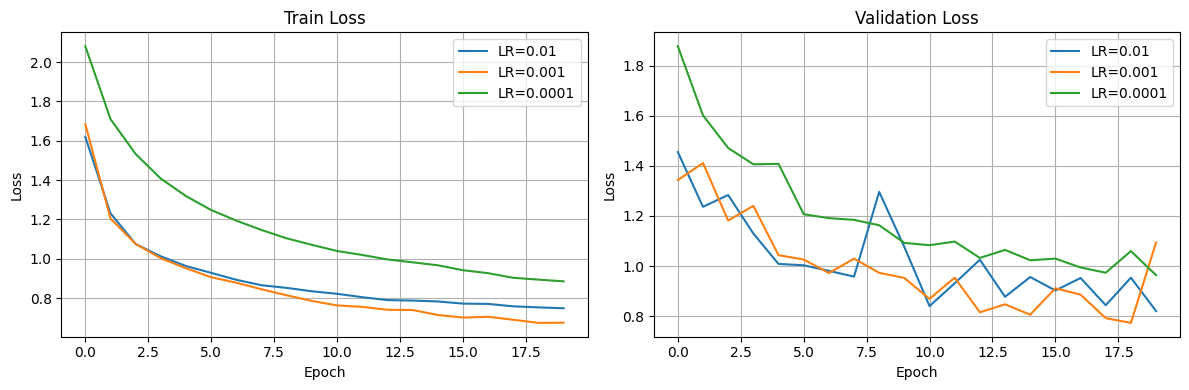

Финальная точность на тест выборке - 0.09278179705142975


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Списки параметров для поиска
learning_rates = [1e-2, 1e-3, 1e-4]
best_acc = 0
best_lr = 0
history = {}

def train_and_validate(lr, epochs=5):
    train_losses = []
    val_losses = []
    val_accs = []
    X_val_tensor = torch.tensor(X_val, dtype= torch.float32) / 255.0
    y_val_tensor = torch.tensor(y_val, dtype= torch.long).flatten()
    y_val_tensor[y_val_tensor == 10] = 0

    model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32 * 3, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Linear(64, 10)
)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # обучаем на части данных для скорости и более правильных весов - меньше samples в лосс
    for i in range(20):
      model.train()
      total_loss = 0
      for batch_x, batch_y in train_loader:
          optimizer.zero_grad()
          pred = model(batch_x)
          loss = criterion(pred, batch_y)
          loss.backward()
          optimizer.step()
          total_loss += loss.item()

      # Валидация
      model.eval()
      with torch.no_grad():
          val_preds = model(X_val_tensor) # Кусок данных для валидации
          val_loss = criterion(val_preds, y_val_tensor)
          val_acc = (torch.argmax(val_preds, dim=1) == y_val_tensor).float().mean().item()
      val_losses.append(val_loss)
      val_accs.append(val_acc)

      avg_loss = total_loss / len(train_loader)
      train_losses.append(avg_loss)
      if i % 5 == 0:
            print(f"  Эпоха {i}, Loss: {total_loss/len(train_loader):.4f}")

    history[lr] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_acc': max(val_accs)
    }

    return max(val_accs), model






for lr in learning_rates:
    print(f"\nОбучение с lr={lr}")
    acc, model = train_and_validate(lr)
    print(f"Точность на валидации: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_lr = lr

print(f"\nЛучший LR: {best_lr}, точность: {best_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lr in learning_rates:
    data = history[lr]
    epochs = range(len(data['train_losses']))
    axes[0].plot(epochs, data['train_losses'], label=f'LR={lr}')
    axes[1].plot(epochs, data['val_losses'], label=f'LR={lr}')

axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1
     ].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long).flatten()
y_test_tensor[y_test_tensor == 10] = 0

best_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 10))

with torch.no_grad():
    test_preds = best_model(X_test_tensor)
    test_acc = (torch.argmax(test_preds, dim=1) == y_test_tensor).float().mean().item()
print(f'Финальная точность на тест выборке - {test_acc}')